# 07 · Pu.1 expression by lesion proximity (exploratory)

Every Pu.1⁺ cell carries its own Pu.1 and Iba1 levels (nuclear mean intensity from the cell table), its
nuclear size / shape, its compartment and its signed distance to the lesion edge. Question: **do
Pu.1⁺ cells in the core express more Pu.1 than those in the rim, the peri-lesion area and further out?**

Compartments: `core`, `rim`, `peri`, `deep`, `distal` in lesion sections (parenchyma only), `meninges`,
and the manual `GM` / `WM` of control sections. Buffer and VBO cells are left out.

How to read it – four things that would otherwise mislead:

* **The unit is the section, not the cell.** With tens of thousands of cells any difference is
  "significant". Each comparison uses the median per section and slide, expressed as log2 ratio to the
  *same* section's distal Pu.1⁺ cells (paired, so scan and staining differences cancel); the two replicate
  slides of a section are averaged and a Wilcoxon signed-rank test runs over sections (n ≤ 8).
* **Crowding.** In packed tissue, signal from touching neighbours can raise a nucleus' mean intensity.
  Zones are compared again at matched local density (nuclei / Pu.1⁺ nuclei within 15 µm).
* **Truncation.** Pu.1⁺ cells were called by a threshold, so their intensities are a truncated
  distribution; the Pu.1⁺ fraction per compartment is shown alongside.
* **Composition.** A higher median can mean more Pu.1 per cell *or* a different mix of cells
  (resident microglia vs infiltrating monocyte-derived macrophages). Intensity alone cannot tell these apart.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

from lesionseg import expression as E
df = E.expression_table(runs)
print(f"{len(df):,} cells with a compartment, {int(df.pu1_pos.sum()):,} Pu.1⁺")
df.groupby("compartment", observed=True).agg(cells=("pu1_pos", "size"), pu1_pos=("pu1_pos", "sum"),
                                             pu1_fraction=("pu1_pos", "mean")).round(3)

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


176,414 cells with a compartment, 54,880 Pu.1⁺


,cells,pu1_pos,pu1_fraction
compartment,,,
core,21898,10236,0.467
rim,17858,7724,0.433
peri,23377,7027,0.301
deep,16678,5037,0.302
distal,32571,9821,0.302
meninges,23641,7023,0.297
GM,27364,6164,0.225
WM,13027,1848,0.142


## Paired per section: Pu.1⁺ cells vs the same section's distal Pu.1⁺ cells

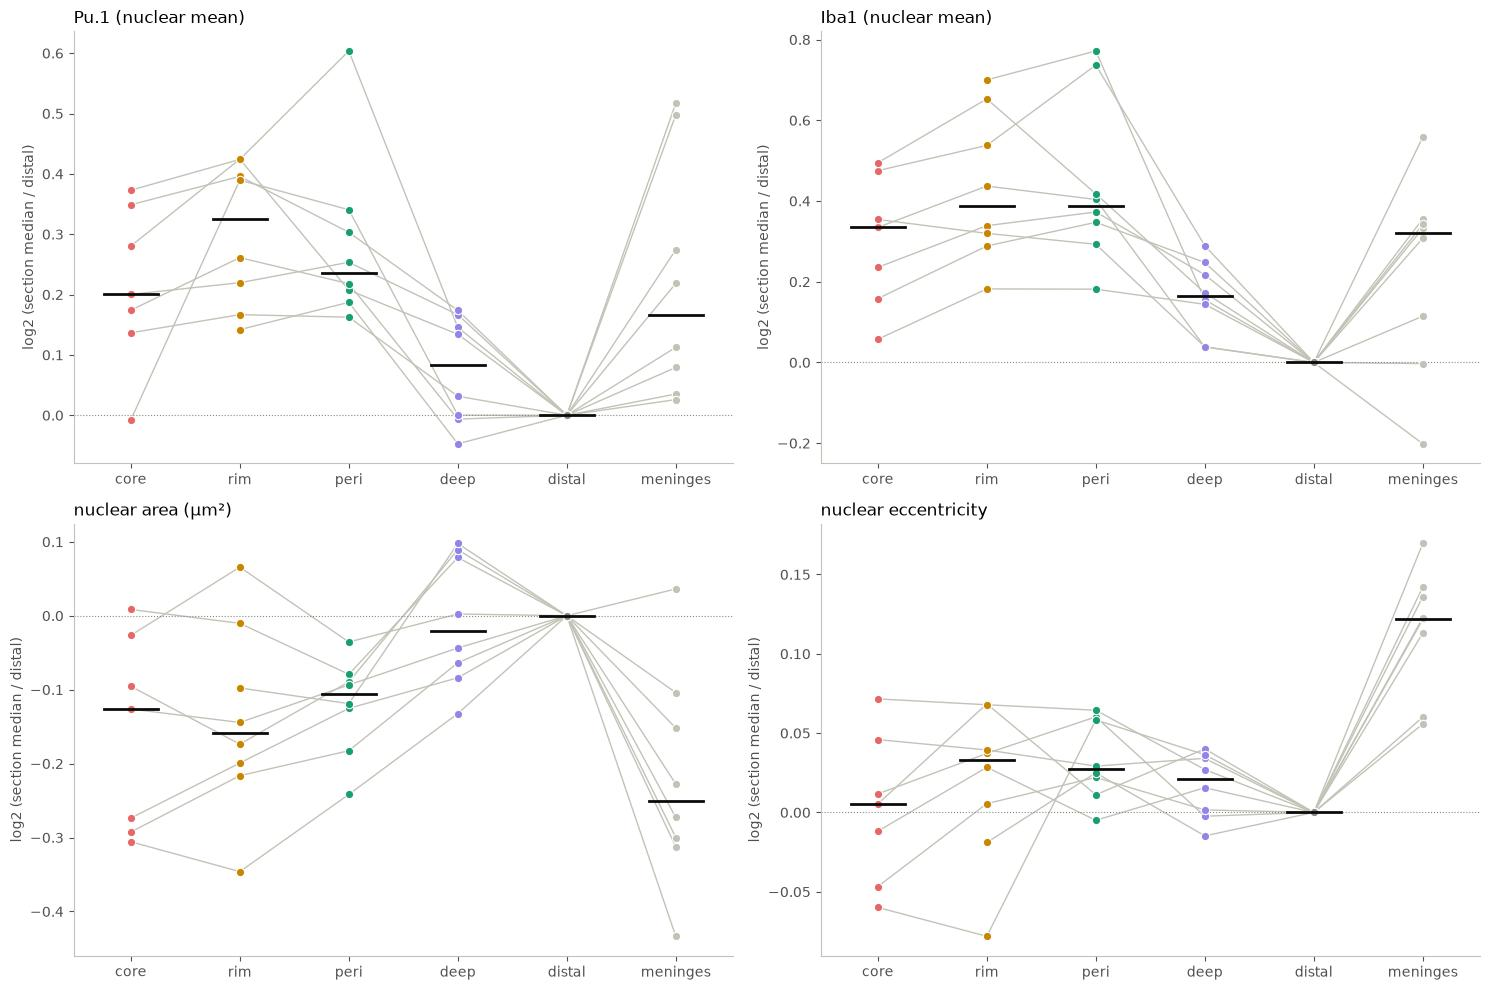

**Pu.1 (nuclear mean)** – fold change = 2^median log2 over sections; Wilcoxon over sections (n ≤ 8, min p = 0.008)

,compartment,n_sections,median_log2_vs_distal,fold_change,sections_higher,wilcoxon_p
0,core,7,0.2003,1.1490,6,0.0312
1,rim,8,0.3254,1.2530,8,0.0078
2,peri,8,0.2358,1.1775,8,0.0078
3,deep,8,0.0830,1.0592,6,0.1094
4,meninges,8,0.1655,1.1216,8,0.0078


**Iba1 (nuclear mean)** – fold change = 2^median log2 over sections; Wilcoxon over sections (n ≤ 8, min p = 0.008)

,compartment,n_sections,median_log2_vs_distal,fold_change,sections_higher,wilcoxon_p
0,core,7,0.3346,1.2610,7,0.0156
1,rim,8,0.3880,1.3086,8,0.0078
2,peri,8,0.3883,1.3089,8,0.0078
3,deep,8,0.1637,1.1202,8,0.0078
4,meninges,8,0.3201,1.2485,6,0.0547


**nuclear area (µm²)** – fold change = 2^median log2 over sections; Wilcoxon over sections (n ≤ 8, min p = 0.008)

,compartment,n_sections,median_log2_vs_distal,fold_change,sections_higher,wilcoxon_p
0,core,7,-0.1263,0.9162,1,0.0312
1,rim,8,-0.1590,0.8956,1,0.0234
2,peri,8,-0.1062,0.9290,0,0.0078
3,deep,8,-0.0207,0.9858,4,1.0000
4,meninges,8,-0.2502,0.8408,1,0.0156


**nuclear eccentricity** – fold change = 2^median log2 over sections; Wilcoxon over sections (n ≤ 8, min p = 0.008)

,compartment,n_sections,median_log2_vs_distal,fold_change,sections_higher,wilcoxon_p
0,core,7,0.0054,1.0037,4,1.0000
1,rim,8,0.0328,1.0230,6,0.3125
2,peri,8,0.0271,1.0190,7,0.0156
3,deep,8,0.0213,1.0149,6,0.0781
4,meninges,8,0.1222,1.0884,8,0.0078


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
tests = {}
for ax, (v, label) in zip(axes.ravel(), E.MARKERS.items()):
    med = E.section_medians(df, v)
    E.plot_paired(med, ax, label)
    tests[label] = E.paired_tests(med)
plt.tight_layout(); plt.show()
for label, t in tests.items():
    display(Markdown(f"**{label}** – fold change = 2^median log2 over sections; Wilcoxon over sections (n ≤ 8, min p = 0.008)"))
    display(t.round(4))

## Gradient: Pu.1 and Iba1 against distance to the lesion edge

Median of Pu.1⁺ cells per distance bin, one line per slide, normalised to the slide's control-section
Pu.1⁺ cells (1 = control level). Negative distances are inside the lesion.

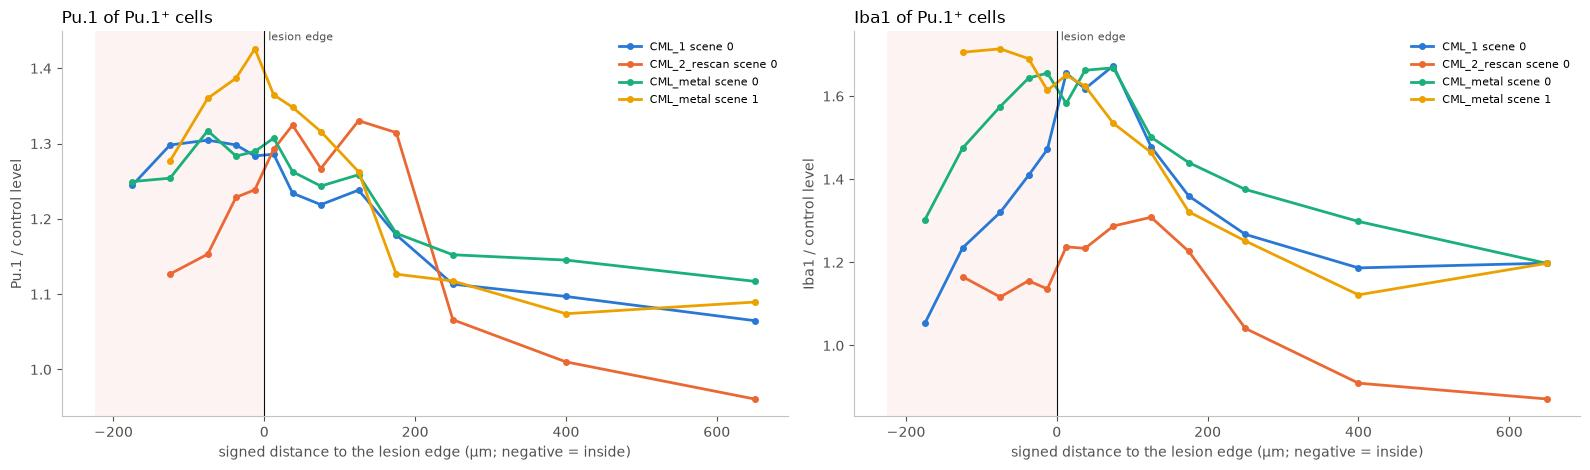

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
E.plot_gradient(E.gradient(df, "Pu1_mean_norm"), axes[0], "Pu.1 of Pu.1⁺ cells", "Pu.1 / control level")
E.plot_gradient(E.gradient(df, "Iba1_mean_norm"), axes[1], "Iba1 of Pu.1⁺ cells", "Iba1 / control level")
plt.tight_layout(); plt.show()

## Crowding check: zones at matched local density

If the lesion effect were only signal bleeding in from packed neighbours, the zones would converge once
local density is matched. Bins are quartiles of the number of nuclei (left) or Pu.1⁺ nuclei (right)
within 15 µm, over Pu.1⁺ cells in lesion sections.

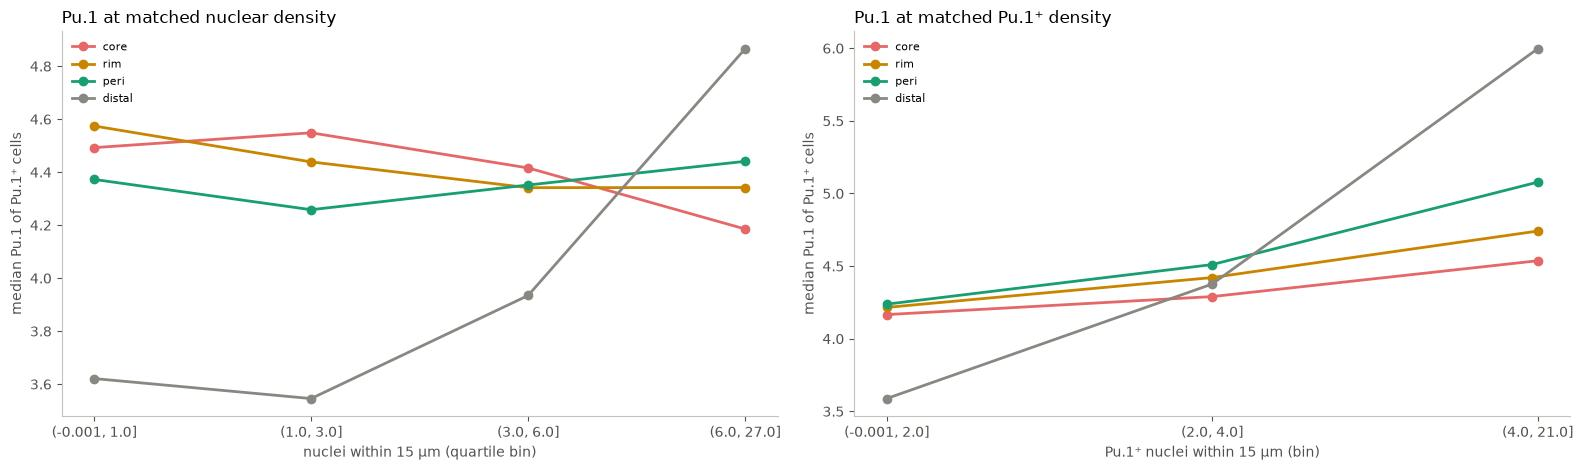

compartment,core,rim,peri,distal
density_bin,,,,
"(-0.001, 1.0]",4.49,4.57,4.37,3.62
"(1.0, 3.0]",4.55,4.44,4.26,3.55
"(3.0, 6.0]",4.42,4.34,4.35,3.93
"(6.0, 27.0]",4.19,4.34,4.44,4.87


compartment,core,rim,peri,distal
density_bin,,,,
"(-0.001, 2.0]",4.17,4.22,4.24,3.59
"(2.0, 4.0]",4.29,4.42,4.51,4.38
"(4.0, 21.0]",4.54,4.74,5.08,6.00


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
t1 = E.density_matched(df, "Pu1_mean", "n_nb_15um")
t2 = E.density_matched(df, "Pu1_mean", "n_pu1_nb_15um")
E.plot_density_matched(t1, axes[0], "Pu.1 at matched nuclear density", "nuclei within 15 µm (quartile bin)")
E.plot_density_matched(t2, axes[1], "Pu.1 at matched Pu.1⁺ density", "Pu.1⁺ nuclei within 15 µm (bin)")
plt.tight_layout(); plt.show()
display(t1.round(2)); display(t2.round(2))

## Distributions (cells pooled – descriptive only, not a test)

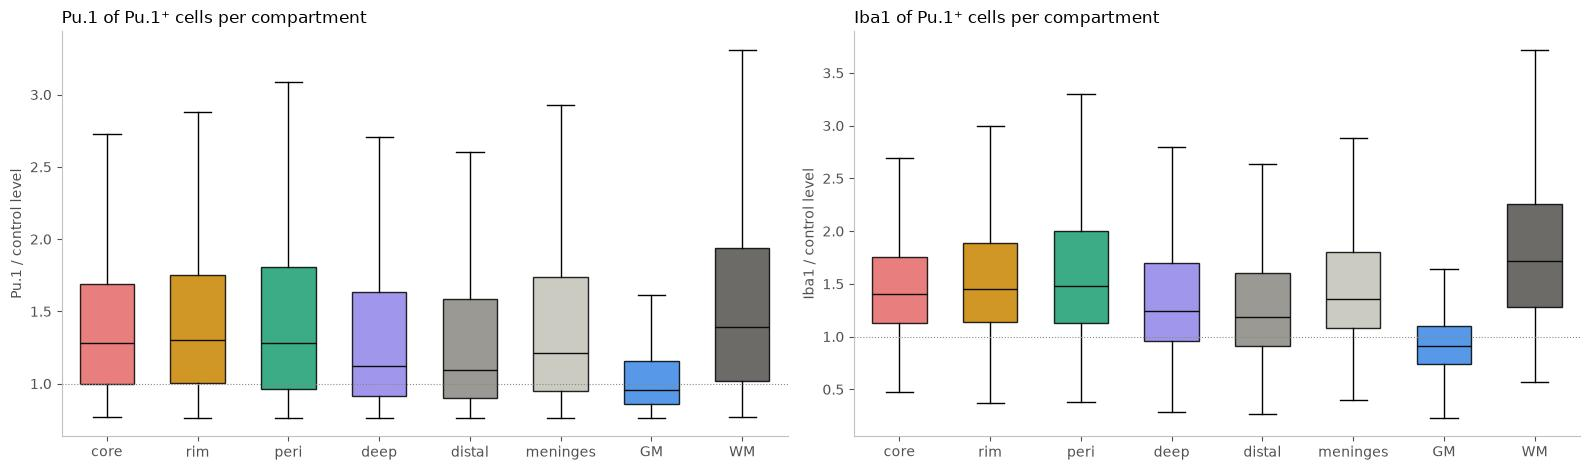

In [5]:
pos = df[df.pu1_pos]
comps = [c for c in E.ORDER if c in set(pos.compartment.astype(str))]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
for ax, v, label in ((axes[0], "Pu1_mean_norm", "Pu.1 / control level"), (axes[1], "Iba1_mean_norm", "Iba1 / control level")):
    data = [pos.loc[pos.compartment == c, v].dropna().to_numpy() for c in comps]
    bp = ax.boxplot(data, showfliers=False, patch_artist=True, widths=0.6, medianprops={"color": "#0b0b0b"})
    for patch, c in zip(bp["boxes"], comps):
        patch.set_facecolor(E.COLORS[c]); patch.set_alpha(0.85)
    ax.set_xticks(range(1, len(comps) + 1), comps); ax.axhline(1, color="#898781", lw=0.8, ls=":")
    ax.set_ylabel(label); ax.set_title(label.split(" /")[0] + " of Pu.1⁺ cells per compartment", loc="left")
plt.tight_layout(); plt.show()

## Where the high-Pu.1 cells are: lesion sections on both slides

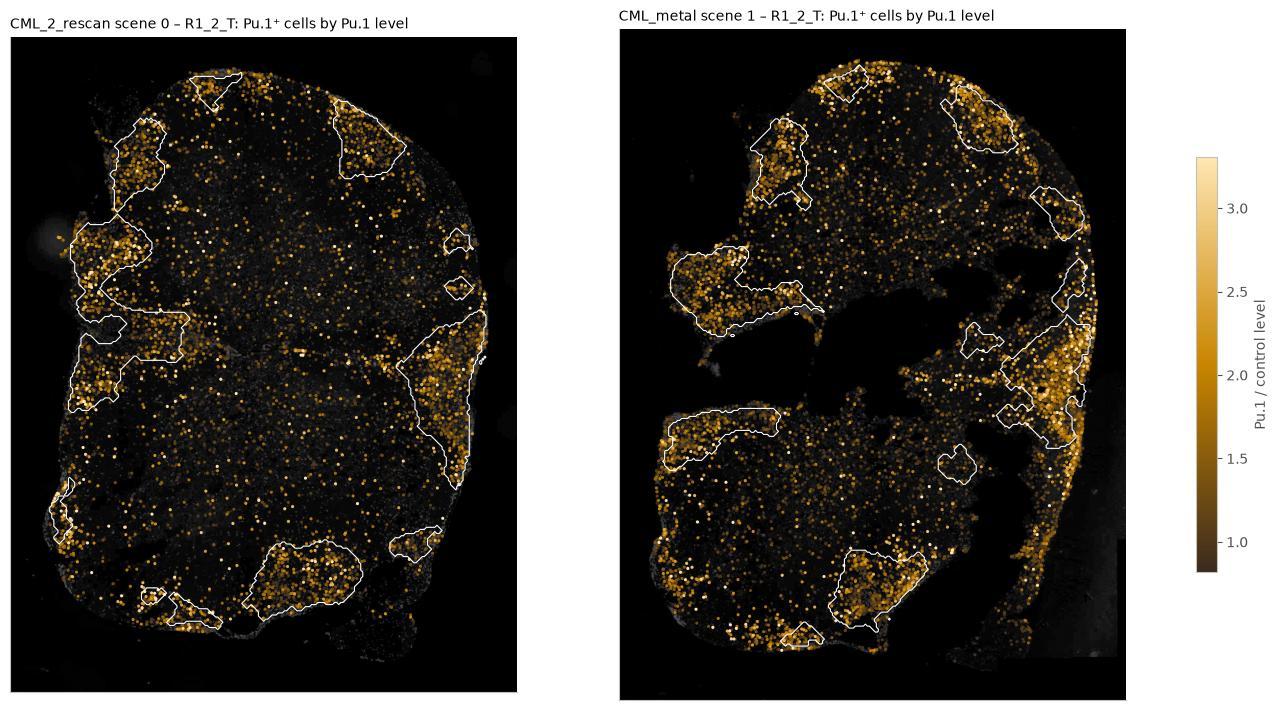

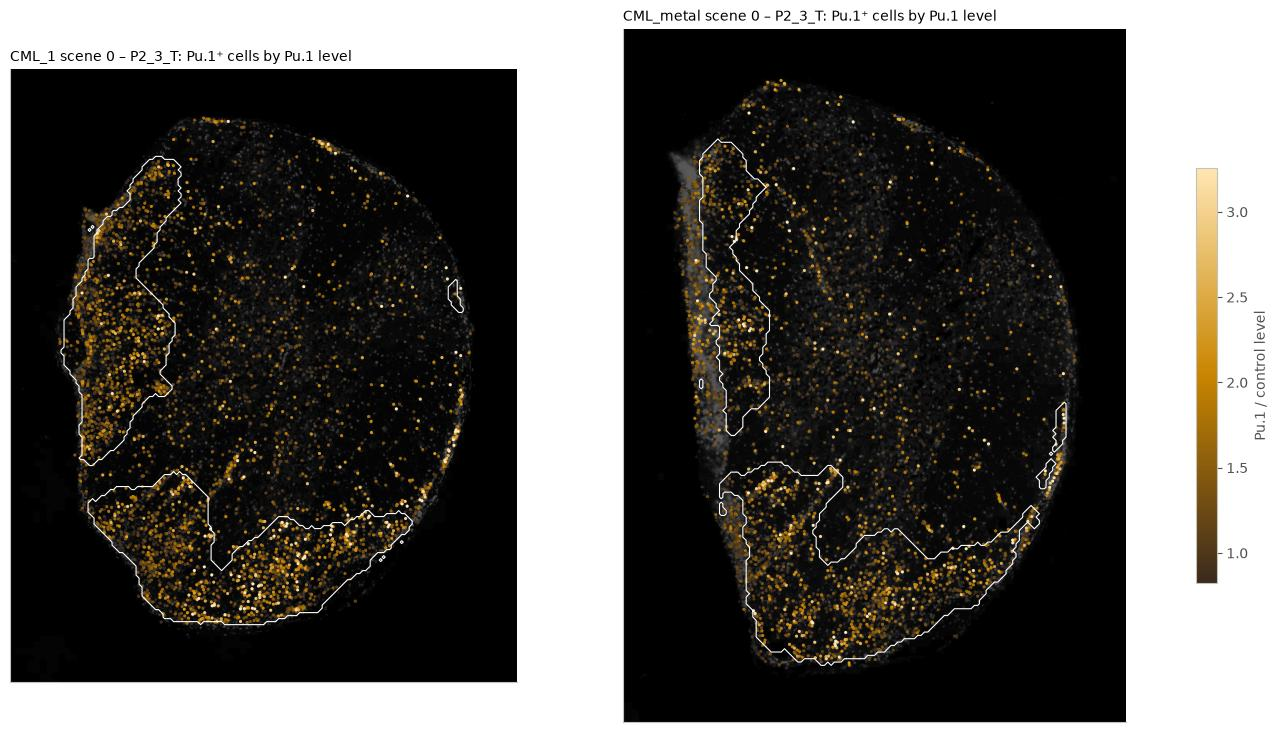

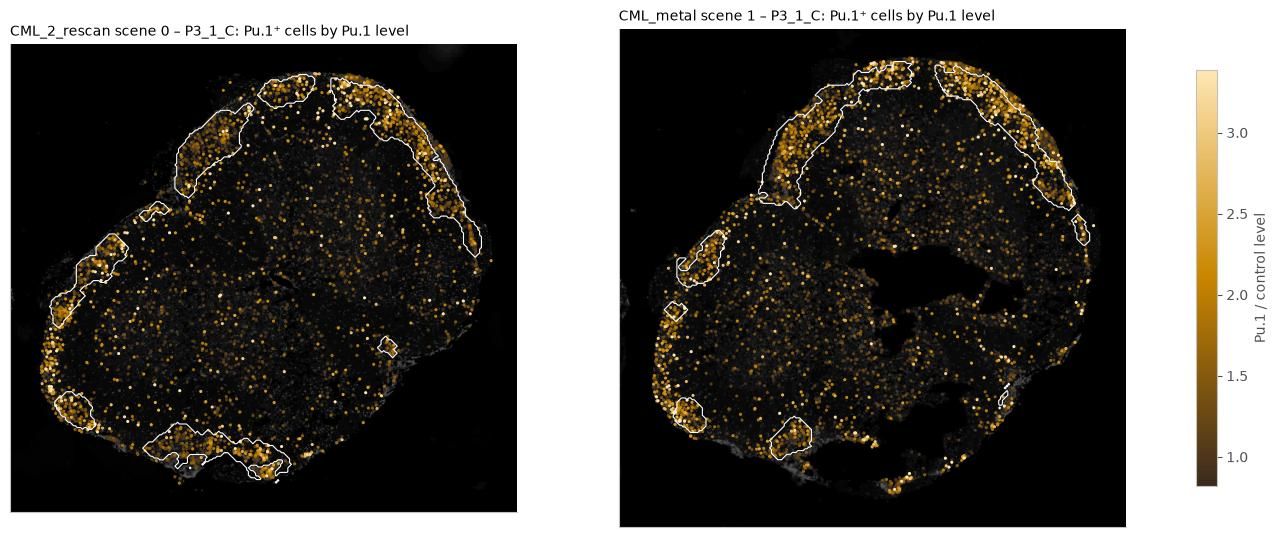

In [6]:
for sec in ["R1_2_T", "P2_3_T", "P3_1_C"]:
    hits = [r for r in runs if sec in set(r.sections.section_name.astype(str))]
    fig, axes = plt.subplots(1, len(hits), figsize=(9 * len(hits), 9), squeeze=False)
    for ax, r in zip(axes.ravel(), hits):
        sc = E.plot_section_map(r, df, sec, ax)
    fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.6, label="Pu.1 / control level")
    plt.show()

## Reading

* Compare the paired panels first: they are the evidence. A compartment counts as different when most
  sections move the same way (`sections_higher`) – the p-values have little power with 8 sections and are
  not corrected for the four markers × five compartments tested.
* If Pu.1 is highest at the **rim** rather than the core, that fits an active edge (recruitment /
  activation at the border) – a hypothesis for the DVP data, which will measure the proteome directly.
* Smaller nuclei together with higher Pu.1 / Iba1 near lesions could mean activated or infiltrating
  myeloid cells; a marker that separates resident microglia from monocyte-derived macrophages
  (e.g. TMEM119 / P2RY12 vs CCR2) would be needed to separate composition from per-cell expression.